In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Datensatz laden und Exploration

In [3]:
df = pd.read_csv("movie_metadata.csv", sep=",")

In [4]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [5]:
df.shape

(5043, 28)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [7]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [8]:
df.isnull().sum().sort_values(ascending=False)

gross                        884
budget                       492
aspect_ratio                 329
content_rating               303
plot_keywords                153
title_year                   108
director_facebook_likes      104
director_name                104
num_critic_for_reviews        50
actor_3_facebook_likes        23
actor_3_name                  23
num_user_for_reviews          21
color                         19
duration                      15
language                      14
actor_2_facebook_likes        13
actor_2_name                  13
facenumber_in_poster          13
actor_1_name                   7
actor_1_facebook_likes         7
country                        5
genres                         0
movie_title                    0
cast_total_facebook_likes      0
movie_imdb_link                0
num_voted_users                0
imdb_score                     0
movie_facebook_likes           0
dtype: int64

In [9]:
# Kategorien zählen
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(col, df[col].nunique())

color 2
director_name 2398
actor_2_name 3032
genres 914
actor_1_name 2097
movie_title 4917
actor_3_name 3521
plot_keywords 4760
movie_imdb_link 4919
language 46
country 65
content_rating 18


movie_title, plot_keywords, movie_imdb_link, actor_3_name droppen, evtl. auch actor_2_name

In [10]:
# Kategorische Variablen nutzen? -> One-Hot-Encoding

In [11]:
df['color'].value_counts()

color
Color               4815
 Black and White     209
Name: count, dtype: int64

# Data Split

In [13]:
X = df.drop('imdb_score', axis=1)
y = df['imdb_score'].copy()

X_train_full,X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train,X_val,y_train,y_val=train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42
)
# Ergebnis: ca. 60% Train, 20% Val, 20% Test

# EDA

In [15]:
# Korrelationen
train_df = X_train.copy()
train_df['imdb_score'] = y_train

train_df.corr(numeric_only=True)['imdb_score'].sort_values()

title_year                  -0.207961
facenumber_in_poster        -0.071553
actor_3_facebook_likes       0.022761
budget                       0.046333
actor_1_facebook_likes       0.065994
cast_total_facebook_likes    0.070512
actor_2_facebook_likes       0.075076
aspect_ratio                 0.085411
director_facebook_likes      0.163138
gross                        0.187837
movie_facebook_likes         0.249628
duration                     0.250274
num_user_for_reviews         0.279461
num_critic_for_reviews       0.302805
num_voted_users              0.410058
imdb_score                   1.000000
Name: imdb_score, dtype: float64

Text(0.5, 1.0, 'Korrelationsheatmap')

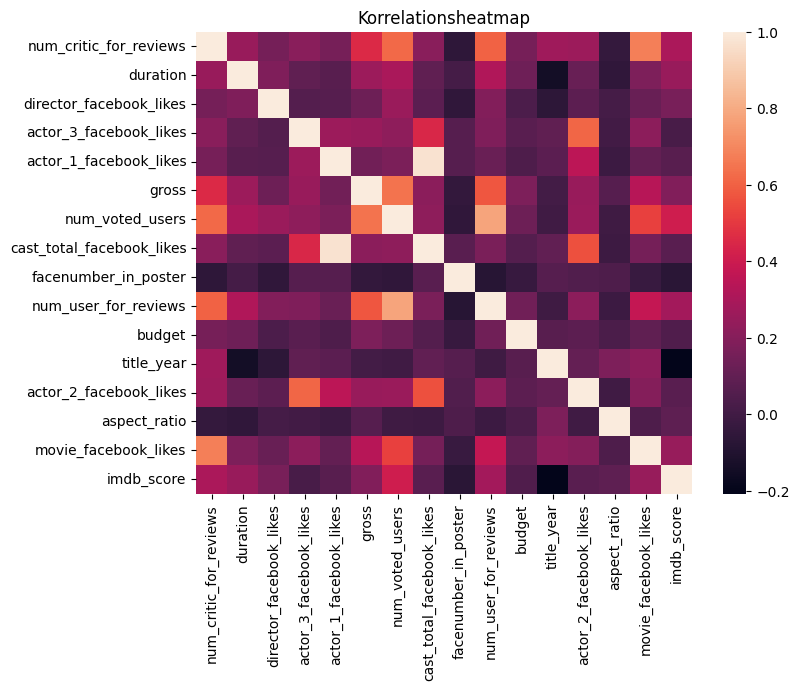

In [20]:
# Heatmap Korrelationen
plt.figure(figsize=(8,6))
sns.heatmap(train_df.corr(numeric_only=True))
plt.title('Korrelationsheatmap')

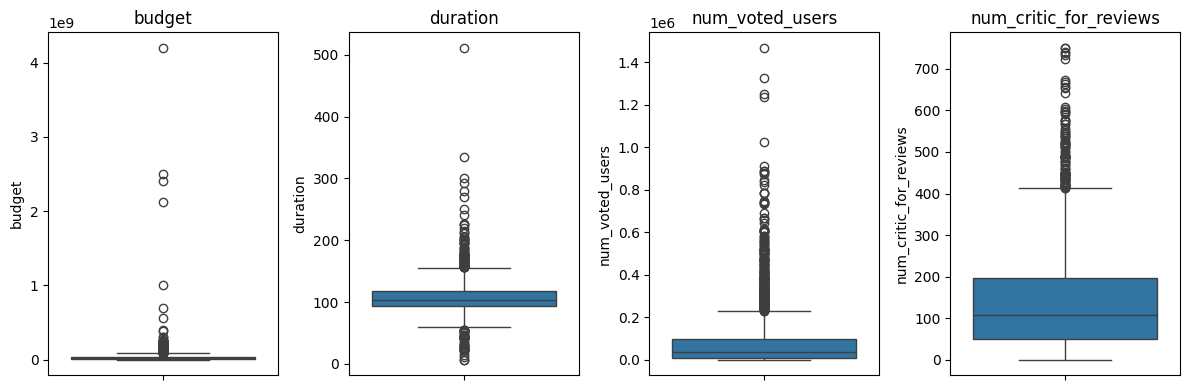

In [21]:
# Boxplots

cols = ['budget', 'duration', 'num_voted_users', 'num_critic_for_reviews']

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i, col in enumerate(cols):
    sns.boxplot(y=train_df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [22]:
# Prozen

num_cols = X_train.select_dtypes(include="number").columns

for col in num_cols:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X_train[
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ]

    pct = len(outliers) / len(X_train) * 100

    print(f"{col}: {pct:.2f}% Ausreißer")

num_critic_for_reviews: 3.74% Ausreißer
duration: 4.76% Ausreißer
director_facebook_likes: 11.80% Ausreißer
actor_3_facebook_likes: 3.01% Ausreißer
actor_1_facebook_likes: 3.40% Ausreißer
gross: 6.02% Ausreißer
num_voted_users: 8.86% Ausreißer
cast_total_facebook_likes: 6.45% Ausreißer
facenumber_in_poster: 3.97% Ausreißer
num_user_for_reviews: 7.80% Ausreißer
budget: 7.54% Ausreißer
title_year: 5.69% Ausreißer
actor_2_facebook_likes: 11.34% Ausreißer
aspect_ratio: 0.93% Ausreißer
movie_facebook_likes: 23.07% Ausreißer


# Preprocessing

# Baseline Modell